# Dedup Results — harbor_tasks_8192

Analyzes `harbor_tasks_8192_deduped/dedup_report.json`:
- How many tasks were dropped vs kept
- Similarity score distribution of dropped pairs
- Which tasks are most frequently duplicated
- Description-length characteristics of kept vs dropped

In [1]:
import json
import re
import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
REPORT = Path('../harbor_tasks_8192_deduped/dedup_report.json')

with open(REPORT) as f:
    report = json.load(f)

print(f"Input tasks : {report['input']:,}")
print(f"Kept        : {report['kept']:,}  ({100*report['kept']/report['input']:.1f}%)")
print(f"Dropped     : {report['dropped']:,}  ({100*report['dropped']/report['input']:.1f}%)")
print(f"Threshold   : {report['threshold']}")

Input tasks : 6,682
Kept        : 4,929  (73.8%)
Dropped     : 1,753  (26.2%)
Threshold   : 0.85


In [3]:
df = pd.DataFrame(report['tasks'])
df['task_num'] = df['task'].str.extract(r'task_(\d+)_').astype(int)
df['desc_len'] = df['description'].str.len()

kept_df    = df[df['status'] == 'kept'].copy()
dropped_df = df[df['status'] == 'dropped'].copy()

print(f"kept rows    : {len(kept_df):,}")
print(f"dropped rows : {len(dropped_df):,}")
print(f"\ndropped columns: {list(dropped_df.columns)}")

kept rows    : 4,929
dropped rows : 1,753

dropped columns: ['task', 'status', 'description', 'duplicate_of', 'similarity', 'task_num', 'desc_len']


---
## Overview

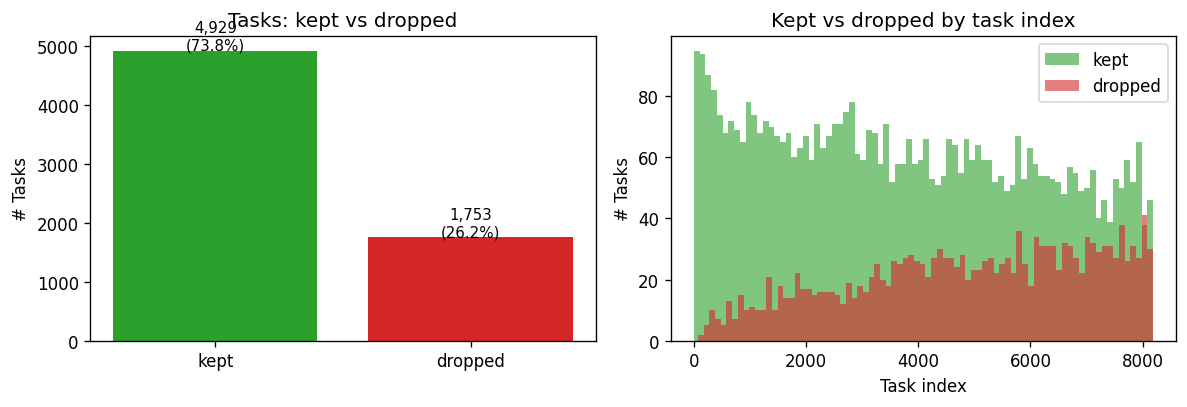

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# kept vs dropped counts
labels = ['kept', 'dropped']
vals   = [report['kept'], report['dropped']]
colors = ['#2ca02c', '#d62728']
axes[0].bar(labels, vals, color=colors)
axes[0].set_title('Tasks: kept vs dropped')
axes[0].set_ylabel('# Tasks')
for i, v in enumerate(vals):
    axes[0].text(i, v + 20, f'{v:,}\n({100*v/report["input"]:.1f}%)', ha='center', fontsize=9)

# kept/dropped by task index (density)
axes[1].hist(kept_df['task_num'],    bins=80, alpha=0.6, label='kept',    color='#2ca02c')
axes[1].hist(dropped_df['task_num'], bins=80, alpha=0.6, label='dropped', color='#d62728')
axes[1].set_xlabel('Task index')
axes[1].set_ylabel('# Tasks')
axes[1].set_title('Kept vs dropped by task index')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Similarity score distribution (dropped pairs)

Similarity stats for 1,753 dropped tasks:
count    1753.0000
mean        0.9053
std         0.0405
min         0.8500
25%         0.8724
50%         0.8970
75%         0.9293
max         1.0000


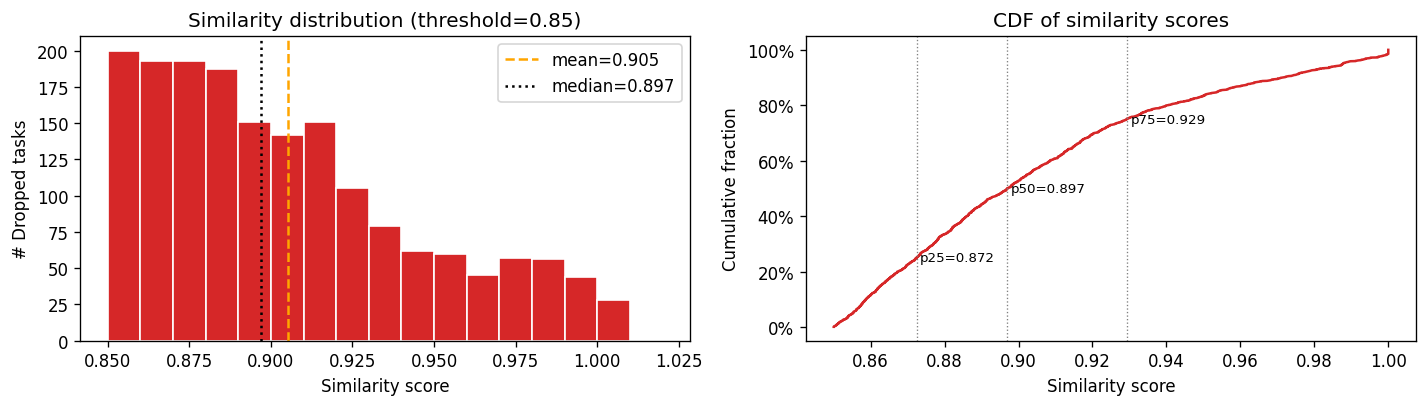


Exact duplicates (sim=1.0): 28
Near-dupes (0.85–0.95)   : 1,461
High-sim (0.95–1.0)      : 264


In [5]:
sims = dropped_df['similarity'].dropna()

print(f"Similarity stats for {len(sims):,} dropped tasks:")
print(sims.describe().round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Histogram
bins = np.arange(0.85, 1.02, 0.01)
axes[0].hist(sims, bins=bins, color='#d62728', edgecolor='white')
axes[0].axvline(sims.mean(), color='orange', linestyle='--', label=f'mean={sims.mean():.3f}')
axes[0].axvline(sims.median(), color='black', linestyle=':', label=f'median={sims.median():.3f}')
axes[0].set_xlabel('Similarity score')
axes[0].set_ylabel('# Dropped tasks')
axes[0].set_title(f'Similarity distribution (threshold={report["threshold"]})')
axes[0].legend()

# Cumulative
sorted_sims = np.sort(sims)
cdf = np.arange(1, len(sorted_sims)+1) / len(sorted_sims)
axes[1].plot(sorted_sims, cdf, color='#d62728')
axes[1].set_xlabel('Similarity score')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('CDF of similarity scores')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for pct in [0.25, 0.5, 0.75]:
    val = np.percentile(sorted_sims, pct*100)
    axes[1].axvline(val, color='grey', linestyle=':', linewidth=0.8)
    axes[1].text(val+0.001, pct, f'p{int(pct*100)}={val:.3f}', fontsize=8, va='center')

plt.tight_layout()
plt.show()

print(f"\nExact duplicates (sim=1.0): {(sims == 1.0).sum():,}")
print(f"Near-dupes (0.85–0.95)   : {((sims >= 0.85) & (sims < 0.95)).sum():,}")
print(f"High-sim (0.95–1.0)      : {((sims >= 0.95) & (sims < 1.0)).sum():,}")

---
## Most-duplicated tasks (top canonical sources)

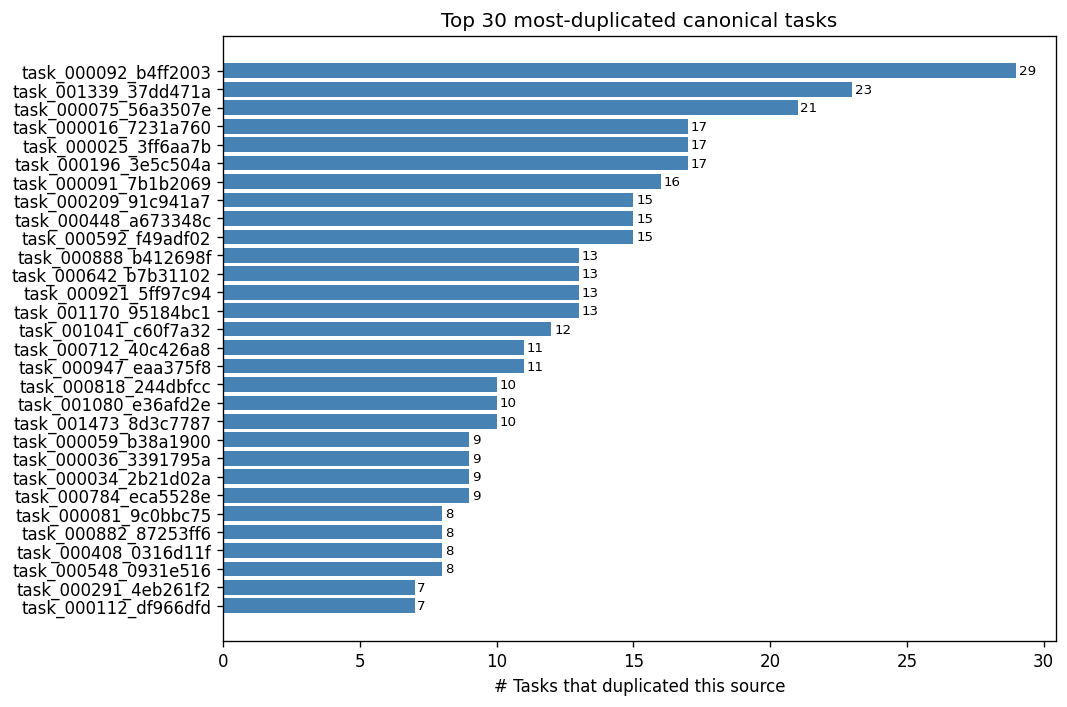


Tasks with ≥5 duplicates  : 30
Tasks with ≥10 duplicates : 20

Top 5 most-duplicated sources:
  [29x] task_000092_b4ff2003: I need a static file server running on port 8080 serving the contents of /home/user/www. Just use Py...
  [23x] task_001339_37dd471a: I need a fresh ED25519 keypair at /home/user/.ssh/id_ed25519 for our new deploy target. No passphras...
  [21x] task_000075_56a3507e: I need a quick health-check script at /home/user/healthcheck.sh that hits http://localhost:8080/stat...
  [17x] task_000016_7231a760: I need an SSH keypair generated at /home/user/.ssh/deploy_key (and the .pub alongside it) — ed25519,...
  [17x] task_000025_3ff6aa7b: I have a CSV at /home/user/inventory/hosts.csv with columns hostname,ip,datacenter,role and I need i...


In [6]:
dup_counts = dropped_df['duplicate_of'].value_counts().head(30)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(dup_counts.index[::-1], dup_counts.values[::-1], color='steelblue')
ax.set_xlabel('# Tasks that duplicated this source')
ax.set_title('Top 30 most-duplicated canonical tasks')
for i, v in enumerate(dup_counts.values[::-1]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTasks with ≥5 duplicates  : {(dup_counts >= 5).sum()}")
print(f"Tasks with ≥10 duplicates : {(dup_counts >= 10).sum()}")
print(f"\nTop 5 most-duplicated sources:")
for task_id, cnt in dup_counts.head(5).items():
    desc = kept_df.loc[kept_df['task'] == task_id, 'description'].values
    if len(desc):
        print(f"  [{cnt}x] {task_id}: {desc[0][:100]}...")

---
## Description length: kept vs dropped

/tmp/ipykernel_207053/2807120165.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


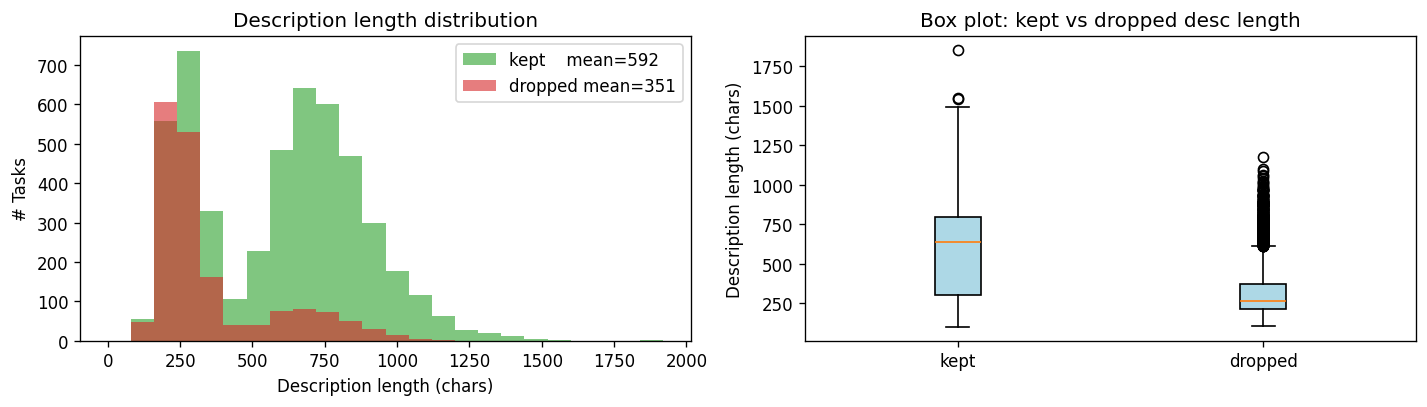

         kept  dropped
count  4929.0   1753.0
mean    592.0    351.0
std     280.0    208.0
min      99.0    102.0
25%     303.0    215.0
50%     635.0    265.0
75%     794.0    373.0
max    1854.0   1177.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

bins = range(0, 2000, 80)
axes[0].hist(kept_df['desc_len'],    bins=bins, alpha=0.6, label=f'kept    mean={kept_df["desc_len"].mean():.0f}',    color='#2ca02c')
axes[0].hist(dropped_df['desc_len'], bins=bins, alpha=0.6, label=f'dropped mean={dropped_df["desc_len"].mean():.0f}', color='#d62728')
axes[0].set_xlabel('Description length (chars)')
axes[0].set_ylabel('# Tasks')
axes[0].set_title('Description length distribution')
axes[0].legend()

axes[1].boxplot(
    [kept_df['desc_len'].values, dropped_df['desc_len'].values],
    labels=['kept', 'dropped'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[1].set_ylabel('Description length (chars)')
axes[1].set_title('Box plot: kept vs dropped desc length')

plt.tight_layout()
plt.show()

print(kept_df['desc_len'].describe().rename('kept').round(0).to_frame().join(
    dropped_df['desc_len'].describe().rename('dropped').round(0)
))

---
## Example dropped pairs

In [8]:
# Show a few near-duplicate pairs across the similarity range
buckets = [
    ('exact (1.0)',         dropped_df[dropped_df['similarity'] == 1.0]),
    ('high (0.95–1.0)',     dropped_df[(dropped_df['similarity'] >= 0.95) & (dropped_df['similarity'] < 1.0)]),
    ('near-dup (0.85–0.95)',dropped_df[(dropped_df['similarity'] >= 0.85) & (dropped_df['similarity'] < 0.95)]),
]

kept_map = kept_df.set_index('task')['description'].to_dict()

for label, bucket in buckets:
    if len(bucket) == 0:
        print(f"--- {label}: none ---\n")
        continue
    sample = bucket.sample(min(2, len(bucket)), random_state=42)
    print(f"=== {label} ({len(bucket):,} total) ===")
    for _, row in sample.iterrows():
        src_desc = kept_map.get(row['duplicate_of'], '(canonical not in kept set)')
        print(f"  KEPT    [{row['duplicate_of']}]: {src_desc[:120]}")
        print(f"  DROPPED [{row['task']}] sim={row['similarity']:.4f}: {row['description'][:120]}")
        print()

=== exact (1.0) (28 total) ===
  KEPT    [task_000811_6780f6bf]: I need MinIO running on port 9000 for our experiment tracker but the config at /home/user/minio/config.env has the wrong
  DROPPED [task_004545_0dcec2fa] sim=1.0000: I need MinIO running on port 9000 for our experiment tracker but the config at /home/user/minio/config.env has the wrong

  KEPT    [task_002600_3ea3465a]: I need a SQLite database at /home/user/app.db with a table called `api_keys` — columns `id` integer primary key autoincr
  DROPPED [task_007936_dd8e50cb] sim=1.0000: I need a SQLite database at /home/user/app.db with a table called `api_keys` — columns `id` integer primary key autoincr

=== high (0.95–1.0) (264 total) ===
  KEPT    [task_000548_0931e516]: I need to pin `requests` to version 2.28.0 in /home/user/project/requirements.txt — it's currently unpinned and I keep g
  DROPPED [task_003432_68f877e1] sim=0.9535: I need to pin the `requests` package to exactly version 2.28.1 in /home/user/project/requ

---
## Dedup rate by task index range

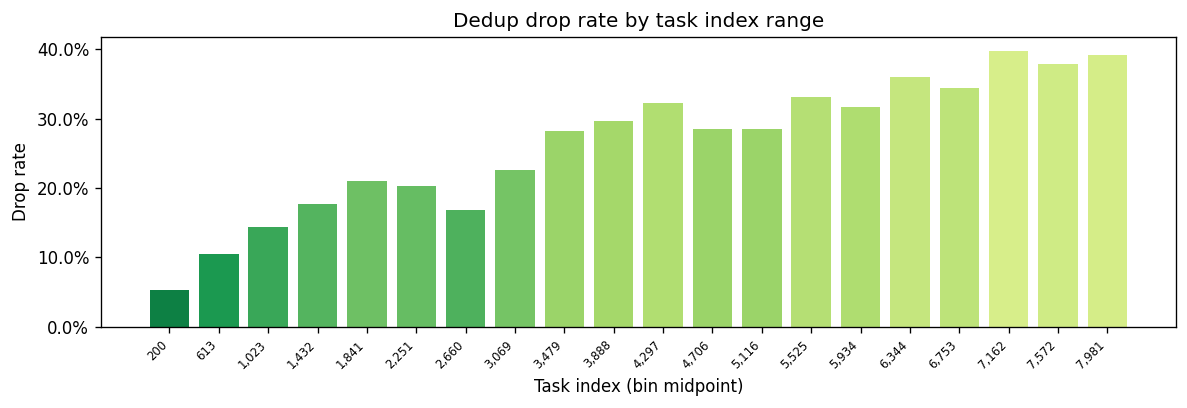

In [9]:
df['chunk'] = pd.cut(df['task_num'], bins=20)
chunk_stats = df.groupby('chunk', observed=True).apply(
    lambda g: pd.Series({'total': len(g), 'dropped': (g['status'] == 'dropped').sum()})
).reset_index()
chunk_stats['drop_rate'] = chunk_stats['dropped'] / chunk_stats['total']
chunk_stats['chunk_mid'] = chunk_stats['chunk'].apply(lambda x: (x.left + x.right) / 2)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(len(chunk_stats)), chunk_stats['drop_rate'],
       color=[plt.cm.RdYlGn_r(v) for v in chunk_stats['drop_rate']])
ax.set_xticks(range(len(chunk_stats)))
ax.set_xticklabels([f'{int(r.chunk_mid):,}' for _, r in chunk_stats.iterrows()],
                   rotation=45, ha='right', fontsize=7)
ax.set_xlabel('Task index (bin midpoint)')
ax.set_ylabel('Drop rate')
ax.set_title('Dedup drop rate by task index range')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

---
## Summary

In [10]:
print("=== Dedup summary ===")
print(f"Input tasks          : {report['input']:,}")
print(f"Kept                 : {report['kept']:,}  ({100*report['kept']/report['input']:.1f}%)")
print(f"Dropped              : {report['dropped']:,}  ({100*report['dropped']/report['input']:.1f}%)")
print(f"Threshold            : {report['threshold']}")
print()
print(f"Exact duplicates     : {(sims == 1.0).sum():,}  ({100*(sims==1.0).mean():.1f}% of dropped)")
print(f"Sim 0.95–1.0         : {((sims >= 0.95) & (sims < 1.0)).sum():,}")
print(f"Sim 0.85–0.95        : {((sims >= 0.85) & (sims < 0.95)).sum():,}")
print()
print(f"Most-duplicated task : {dup_counts.index[0]}  ({dup_counts.iloc[0]} copies dropped)")
print(f"Unique canonical src : {dropped_df['duplicate_of'].nunique():,}  (sources that had ≥1 dup)")

=== Dedup summary ===
Input tasks          : 6,682
Kept                 : 4,929  (73.8%)
Dropped              : 1,753  (26.2%)
Threshold            : 0.85

Exact duplicates     : 28  (1.6% of dropped)
Sim 0.95–1.0         : 264
Sim 0.85–0.95        : 1,461

Most-duplicated task : task_000092_b4ff2003  (29 copies dropped)
Unique canonical src : 830  (sources that had ≥1 dup)
